In [14]:
import pandas as pd
import re
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# IndoBERT
from transformers import pipeline
from transformers import AutoModelForSequenceClassification

from keybert import KeyBERT
from collections import Counter

# LOAD DATA
df = pd.read_csv("dataset/sentiment_NetizenIndonesianLangugage.csv")
# df = pd.read_excel("dataset/dataset_ekonomi_indonesia_2026.xlsx")



In [2]:
label2id = {
    'negatif': 0,
    'netral': 1,
    'positif': 2
}

id2label = {
    0: 'negatif',
    1: 'netral',
    2: 'positif'
}

# hapus NaN dulu
df = df.dropna(subset=['sentiment'])

df['Sentiment'] = df['sentiment'].map(label2id)

In [ ]:

# PREPROCESSING BERT

def preprocess_bert(text):
    text = str(text).lower()

    # hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus html
    text = re.sub(r'<.*?>', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # normalisasi huruf berulang
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan preprocessing
df['clean_for_bert'] = df['review_text'].apply(preprocess_bert)

In [5]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_for_bert'],
    df['Sentiment'],
    test_size=0.2,
    stratify=df['Sentiment'],
    random_state=42
)

In [6]:
tokenizer = AutoTokenizer.from_pretrained(
    "indobenchmark/indobert-base-p1"
)

In [7]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [8]:
from datasets import Dataset
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': list(train_labels)
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': list(test_labels)
})

In [9]:
# model IndoBERT
model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=10
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [11]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc
    }

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [13]:
trainer.train()

c:\Users\asust\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000552,0.000423,1.000000
2,0.000294,0.000227,1.000000
3,0.000249,0.000192,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\asust\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\asust\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=660, training_loss=0.04196006316677526, metrics={'train_runtime': 2100.1924, 'train_samples_per_second': 2.505, 'train_steps_per_second': 0.314, 'total_flos': 78419104137612.0, 'train_loss': 0.04196006316677526, 'epoch': 3.0})

In [18]:
# buat pipeline classifier
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

In [19]:
def predict_sentiment(text):

    result = classifier(
        text,
        truncation=True,
        max_length=128
    )[0]

    label = result['label'].lower()
    score = result['score']

    label_map = {
        'label_0': id2label[0],
        'label_1': id2label[1],
        'label_2': id2label[2]
    }

    return {
        "labels": label_map.get(label, label),
        "score": round(score, 4)
    }

In [20]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    test_labels,
    y_pred,
    target_names=id2label.values()
))

c:\Users\asust\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00       124
      netral       1.00      1.00      1.00       109
     positif       1.00      1.00      1.00       206

    accuracy                           1.00       439
   macro avg       1.00      1.00      1.00       439
weighted avg       1.00      1.00      1.00       439



In [22]:
import torch
texts = [
    "mana seperei gratis nya wok",
    "Tak kusangka komentar tiktok keluar dari mulut presiden😂",
    "rakyat di desa gak pake dollar kok bro pikir semua penduduk di indonesia itu tinggal di desa emang ada ada aja ini si wowok"
]

# tokenize
inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# predict
outputs = model(**inputs)

# ambil prediksi
preds = torch.argmax(outputs.logits, dim=1)

# convert label ke text
hasil = [id2label[p.item()] for p in preds]

# tampilkan
for text, pred in zip(texts, hasil):
    print(f"Teks: {text}")
    print(f"Prediksi: {pred}")
    print("-" * 50)

Teks: mana seperei gratis nya wok
Prediksi: netral
--------------------------------------------------
Teks: Tak kusangka komentar tiktok keluar dari mulut presiden😂
Prediksi: negatif
--------------------------------------------------
Teks: rakyat di desa gak pake dollar kok bro pikir semua penduduk di indonesia itu tinggal di desa emang ada ada aja ini si wowok
Prediksi: negatif
--------------------------------------------------


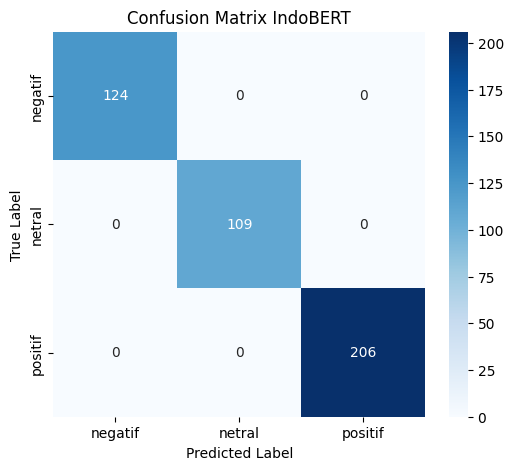

In [32]:
# confusion matrix
cm = confusion_matrix(test_labels, y_pred)

# plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=id2label.values(),
    yticklabels=id2label.values()
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix IndoBERT')

plt.show()